# Semana 6: Árboles de Decisión y Random Forest
## Notebook de Ejercicios (NB2) – Riesgo Crediticio

**Propósito:** Aplicar árboles de decisión y Random Forest a un problema real de clasificación: evaluación de riesgo crediticio.

**Docente:** Carlos César Sánchez Coronel

**Objetivos de aprendizaje:**
- Entrenar y visualizar un árbol de decisión para interpretar sus reglas.
- Entrenar un Random Forest y comparar su rendimiento con el árbol simple.
- Analizar la importancia de características y extraer implicaciones de negocio.
- Optimizar hiperparámetros con GridSearchCV.
- Evaluar modelos con AUC-ROC y otras métricas.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y fijamos la semilla para reproducibilidad.

In [1]:
# Importamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Semilla
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Carga del Dataset: German Credit

El dataset **German Credit** contiene información sobre solicitantes de crédito y una clasificación de riesgo (bueno o malo). Está disponible en el repositorio UCI.

In [2]:
# URL del dataset (UCI)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

# Nombres de las columnas según la documentación
column_names = [
    'status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installment', 'housing',
    'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'target'
]

# Cargamos los datos
df = pd.read_csv(url, sep=' ', header=None, names=column_names)

# La variable objetivo: 1 = bueno, 2 = malo (convertimos a 0/1)
df['target'] = df['target'].map({1: 0, 2: 1})  # 0 = bueno, 1 = malo (riesgo)

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: (1000, 21)

Primeras 5 filas:


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   status             1000 non-null   object
 1   duration           1000 non-null   int64 
 2   credit_history     1000 non-null   object
 3   purpose            1000 non-null   object
 4   credit_amount      1000 non-null   int64 
 5   savings            1000 non-null   object
 6   employment         1000 non-null   object
 7   installment_rate   1000 non-null   int64 
 8   personal_status    1000 non-null   object
 9   other_debtors      1000 non-null   object
 10  residence_since    1000 non-null   int64 
 11  property           1000 non-null   object
 12  age                1000 non-null   int64 
 13  other_installment  1000 non-null   object
 14  housing            1000 non-null   object
 15  existing_credits   1000 non-null   int64 
 16  job                1000 non-null   object
 

Distribución de clases:
target
0    700
1    300
Name: count, dtype: int64

Porcentaje de riesgo malo (clase 1): 30.00%


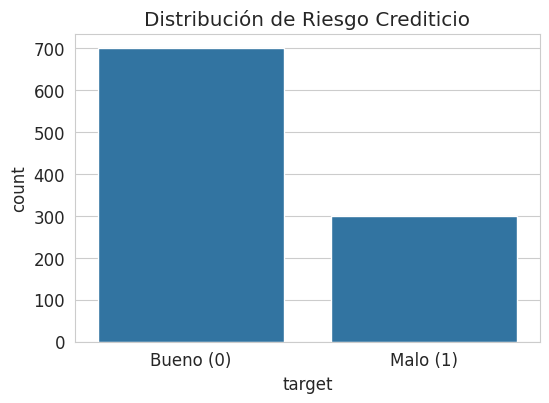

In [4]:
# Distribución de la variable objetivo
print("Distribución de clases:")
print(df['target'].value_counts())
print(f"\nPorcentaje de riesgo malo (clase 1): {df['target'].mean()*100:.2f}%")

# Visualización
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Distribución de Riesgo Crediticio')
plt.xticks([0, 1], ['Bueno (0)', 'Malo (1)'])
plt.show()

---
## 2. Preprocesamiento de Datos

El dataset contiene variables numéricas y categóricas. Para los árboles, no es necesario escalar, pero sí codificar las categóricas.

In [5]:
# Separamos características y objetivo
X = df.drop('target', axis=1)
y = df['target']

# Identificamos columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=[object]).columns.tolist()

print(f"Columnas numéricas: {numeric_cols}")
print(f"Columnas categóricas: {categorical_cols}")

# Codificamos variables categóricas con one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nDimensiones después de codificar: {X_encoded.shape}")
X_encoded.head()

Columnas numéricas: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'people_liable']
Columnas categóricas: ['status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment', 'housing', 'job', 'telephone', 'foreign_worker']

Dimensiones después de codificar: (1000, 48)


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable,status_A12,status_A13,status_A14,...,property_A124,other_installment_A142,other_installment_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [6]:
# Dividimos en entrenamiento y prueba (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")
print(f"Proporción de riesgo en train: {y_train.mean():.3f}")
print(f"Proporción de riesgo en test: {y_test.mean():.3f}")

Tamaño de entrenamiento: (700, 48)
Tamaño de prueba: (300, 48)
Proporción de riesgo en train: 0.300
Proporción de riesgo en test: 0.300


---
## 3. Árbol de Decisión: Entrenamiento y Visualización

Entrenamos un árbol de decisión con profundidad limitada para poder visualizarlo e interpretarlo.

=== Árbol de Decisión (max_depth=3) ===
Accuracy: 0.6900
AUC-ROC: 0.6853

Reporte de clasificación:
              precision    recall  f1-score   support

       Bueno       0.79      0.75      0.77       210
        Malo       0.49      0.54      0.51        90

    accuracy                           0.69       300
   macro avg       0.64      0.65      0.64       300
weighted avg       0.70      0.69      0.69       300



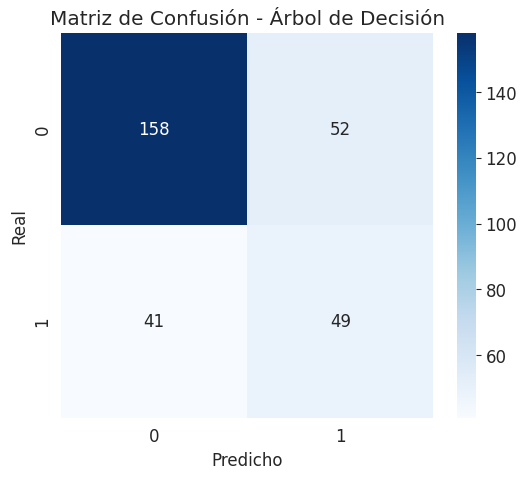

In [7]:
# Entrenamos un árbol con profundidad 3 para facilitar la visualización
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Métricas
print("=== Árbol de Decisión (max_depth=3) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_dt):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=['Bueno', 'Malo']))

# Matriz de confusión
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### 3.1. Visualización del Árbol

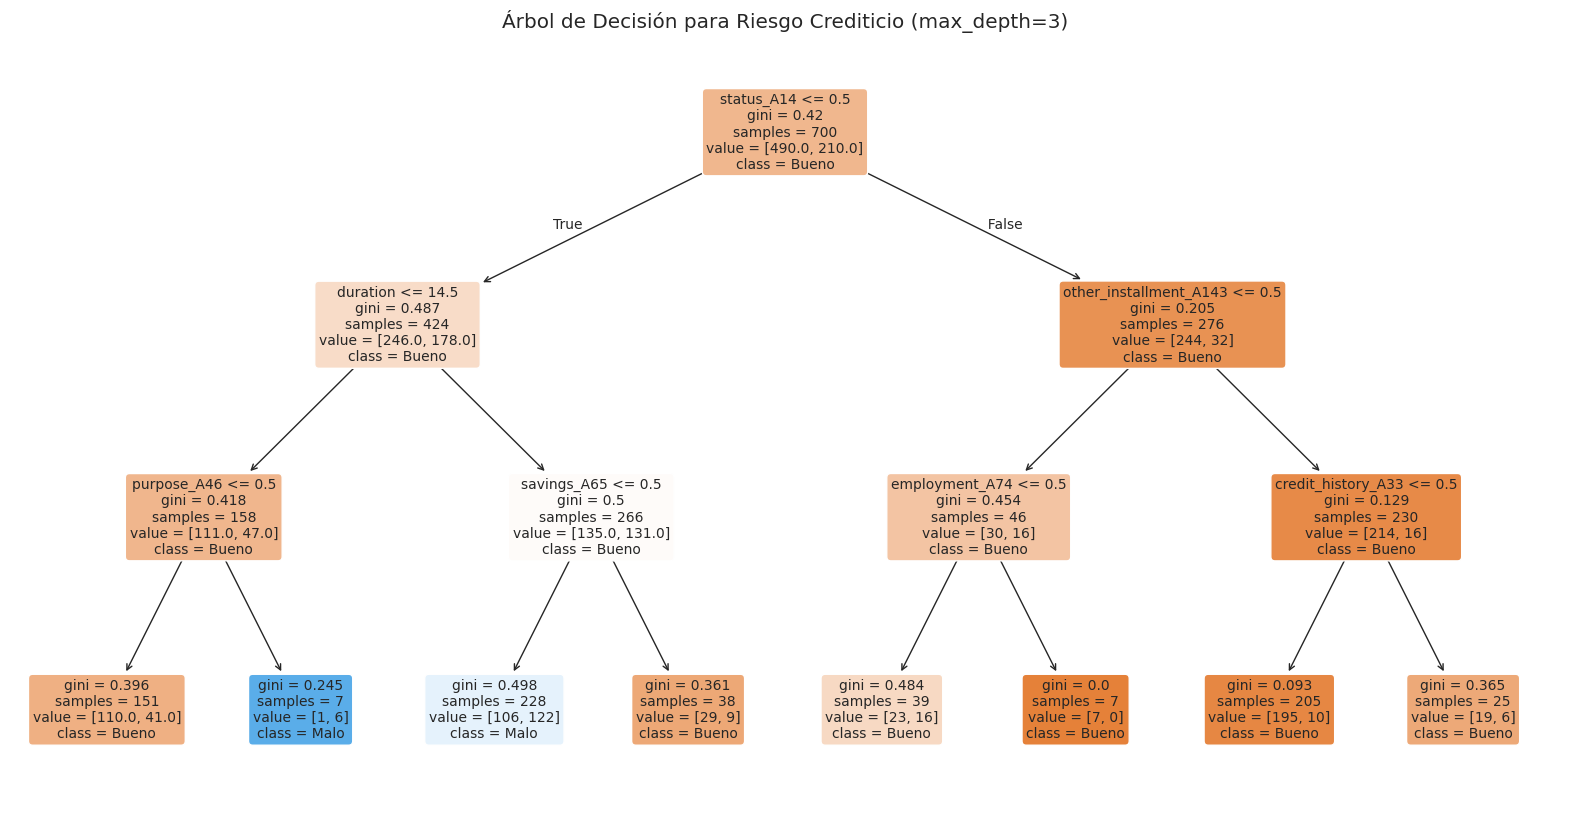

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X_encoded.columns,
          class_names=['Bueno', 'Malo'], rounded=True, fontsize=10)
plt.title('Árbol de Decisión para Riesgo Crediticio (max_depth=3)')
plt.show()

### 3.2. Interpretación del Árbol

Podemos extraer reglas de decisión del árbol. Por ejemplo:
- Si la duración del crédito es <= X y el historial crediticio es Y, entonces...

Esta interpretabilidad es clave en entornos regulados como el bancario.

In [9]:
# Extraemos las reglas del árbol (texto)
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=list(X_encoded.columns))
print(tree_rules)

|--- status_A14 <= 0.50
|   |--- duration <= 14.50
|   |   |--- purpose_A46 <= 0.50
|   |   |   |--- class: 0
|   |   |--- purpose_A46 >  0.50
|   |   |   |--- class: 1
|   |--- duration >  14.50
|   |   |--- savings_A65 <= 0.50
|   |   |   |--- class: 1
|   |   |--- savings_A65 >  0.50
|   |   |   |--- class: 0
|--- status_A14 >  0.50
|   |--- other_installment_A143 <= 0.50
|   |   |--- employment_A74 <= 0.50
|   |   |   |--- class: 0
|   |   |--- employment_A74 >  0.50
|   |   |   |--- class: 0
|   |--- other_installment_A143 >  0.50
|   |   |--- credit_history_A33 <= 0.50
|   |   |   |--- class: 0
|   |   |--- credit_history_A33 >  0.50
|   |   |   |--- class: 0



---
## 4. Random Forest: Entrenamiento y Comparación

=== Random Forest (default) ===
Accuracy: 0.7600
AUC-ROC: 0.7769

Reporte de clasificación:
              precision    recall  f1-score   support

       Bueno       0.76      0.95      0.85       210
        Malo       0.74      0.31      0.44        90

    accuracy                           0.76       300
   macro avg       0.75      0.63      0.64       300
weighted avg       0.76      0.76      0.72       300



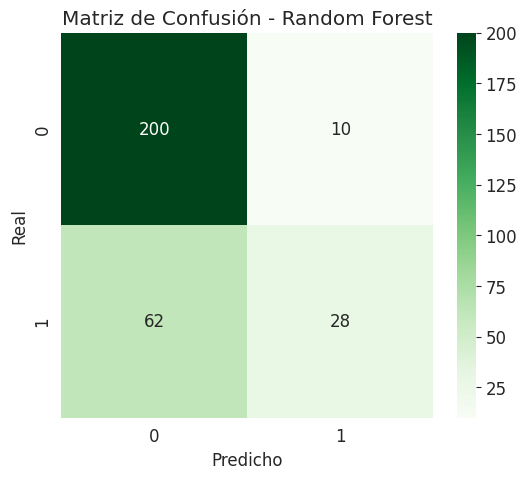

In [10]:
# Entrenamos Random Forest con parámetros por defecto
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['Bueno', 'Malo']))

# Matriz de confusión
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### 4.1. Comparación de Curvas ROC

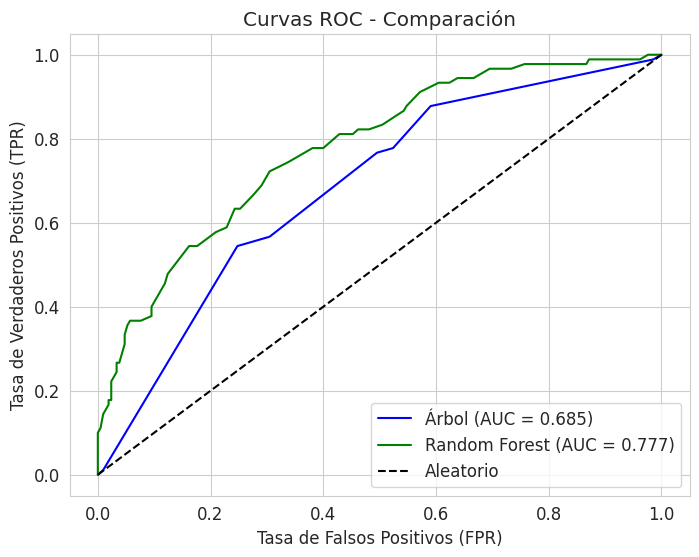

In [11]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, 'b-', label=f'Árbol (AUC = {auc(fpr_dt, tpr_dt):.3f})')
plt.plot(fpr_rf, tpr_rf, 'g-', label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación')
plt.legend()
plt.grid(True)
plt.show()

---
## 5. Importancia de Características y Análisis de Negocio

Random Forest proporciona la importancia de cada variable (basada en reducción de impureza). Esto nos ayuda a entender qué factores influyen más en el riesgo crediticio.

=== Top 10 Características más Importantes ===
            Característica  Importancia
1            credit_amount     0.118221
4                      age     0.088128
0                 duration     0.086643
9               status_A14     0.069580
2         installment_rate     0.040345
3          residence_since     0.039991
40  other_installment_A143     0.025575
26             savings_A65     0.022853
7               status_A12     0.022135
13      credit_history_A34     0.021226


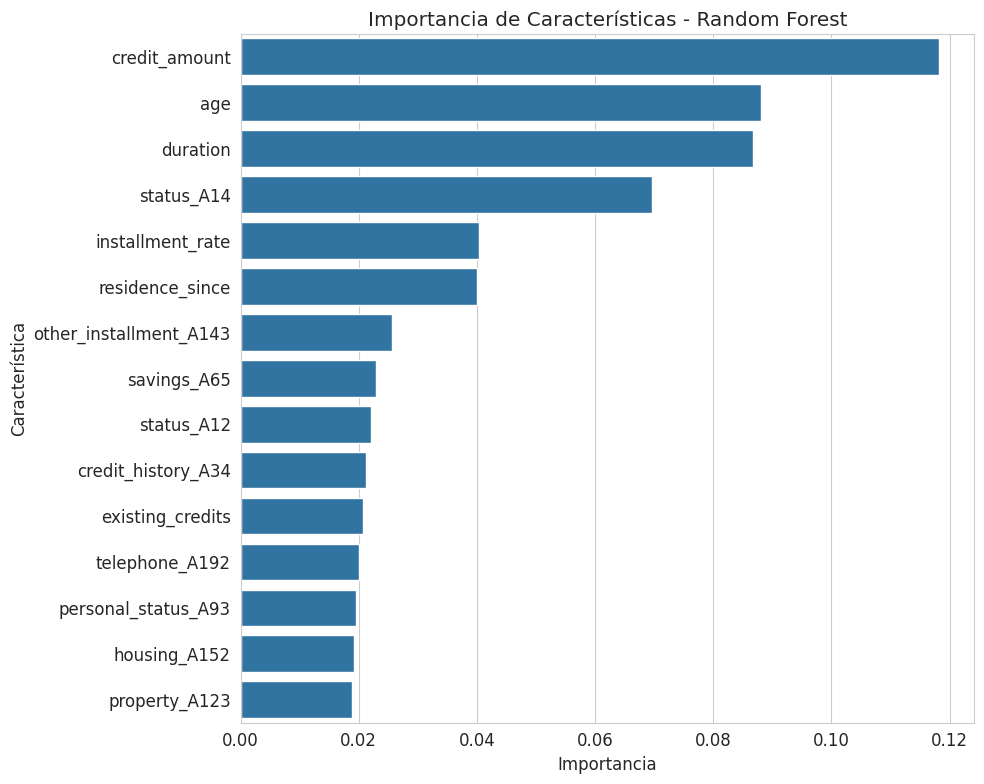

In [12]:
# Importancia de características
importances = rf.feature_importances_
feature_names = X_encoded.columns

# Creamos DataFrame ordenado
imp_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=False)

# Mostramos las 10 más importantes
print("=== Top 10 Características más Importantes ===")
print(imp_df.head(10))

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(15), x='Importancia', y='Característica')
plt.title('Importancia de Características - Random Forest')
plt.tight_layout()
plt.show()

### 5.1. Análisis de Negocio

Basado en la importancia de características, podemos extraer conclusiones para el negocio:

- **¿Qué factores son más determinantes del riesgo?** (ej. duración del crédito, historial crediticio, monto solicitado).
- **Implicaciones para la política de crédito:**
  - Si la duración del crédito es muy importante, podríamos limitar la duración máxima para ciertos perfiles.
  - Si el historial crediticio es clave, debemos obtener información detallada de burós de crédito.
  - Si el propósito del crédito es relevante, podríamos tener tasas diferenciadas según el uso.

Estas decisiones deben basarse en datos y alinearse con el apetito de riesgo del banco.

---
## 6. Ajuste de Hiperparámetros con GridSearchCV

Optimizamos los hiperparámetros más importantes de Random Forest.

In [13]:
# Definimos el grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Configuramos GridSearchCV
rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor AUC-ROC en CV: {grid_search.best_score_:.4f}")

# Evaluamos el mejor modelo en test
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nAUC-ROC en test: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}
Mejor AUC-ROC en CV: 0.7690

AUC-ROC en test: 0.7959
Accuracy en test: 0.7600


## 7. Comparación Final de Modelos

In [14]:
# Resultados comparativos
comparacion = pd.DataFrame({
    'Modelo': ['Árbol (max_depth=3)', 'Random Forest (default)', 'Random Forest (optimizado)'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_best)],
    'AUC-ROC': [roc_auc_score(y_test, y_proba_dt), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_best)]
})

print("=== Comparación de Modelos ===")
comparacion.round(4)

=== Comparación de Modelos ===


,Modelo,Accuracy,AUC-ROC
0,Árbol (max_depth=3),0.69,0.6853
1,Random Forest (default),0.76,0.7769
2,Random Forest (optimizado),0.76,0.7959


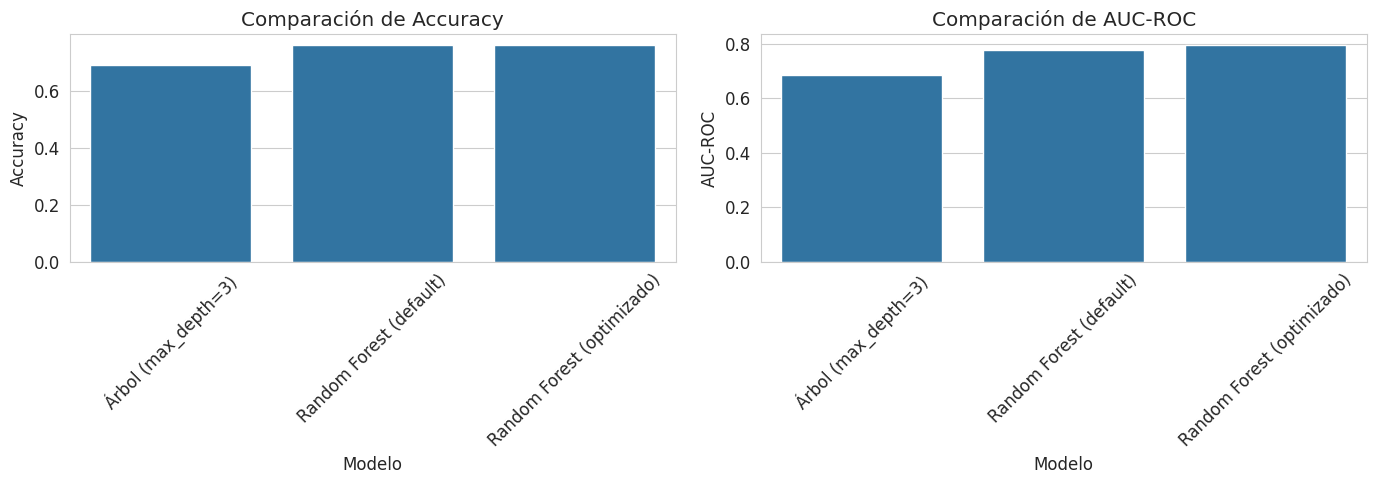

In [15]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparacion, x='Modelo', y='Accuracy', ax=axes[0])
axes[0].set_title('Comparación de Accuracy')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=comparacion, x='Modelo', y='AUC-ROC', ax=axes[1])
axes[1].set_title('Comparación de AUC-ROC')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 8. Conclusiones

En este notebook hemos aplicado árboles de decisión y Random Forest a un problema real de riesgo crediticio:

✔️ **Árbol de decisión**: Modelo interpretable, podemos visualizar sus reglas y entender las decisiones.
✔️ **Random Forest**: Mejora la precisión y el AUC respecto al árbol simple, pero pierde interpretabilidad global.
✔️ **Importancia de características**: Identificamos los factores más relevantes para el riesgo crediticio (duración, historial, monto, etc.).
✔️ **Implicaciones de negocio**: Podemos usar esta información para ajustar políticas de crédito.
✔️ **Optimización de hiperparámetros**: GridSearchCV mejora el rendimiento del modelo.

**Lección clave**: En problemas donde la interpretabilidad es crucial (como crédito o salud), un árbol simple puede ser preferible a pesar de su menor precisión. Random Forest es mejor cuando la prioridad es la precisión predictiva.

---
**Fin del Notebook de Ejercicios - Semana 6**